In [ ]:
'''
여전히 2025년 9월6일 토요일입니다!!

주말에 몰아서 공부하는 나쁜 습관.. 다음주부터는 주중에 노력합시다!
'''

# 탐색적 데이터 분석 - 상관분석과 교차분석

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. 상관분석

In [ ]:
'''
상관분석은 두 변수간의 선형적 관계를 평가하는 통계 기법이다.
두 변수간 어느정도 관계가 있는지 파악하는 절차이며,
상관계수를 도출해 관계의 강도와 방향을 평가한다.


R값이 
0.3 이하면 약한 상관관계,
0.7 미만은 중간 정도 상관관계,
0.7 이상은 강한 상관관계로 평가한다.


내가 배운 재무관리에서
1과 2의 공분산 = 상관계수 * 표준편차1 * 표준편차2 이며
포트폴리오 구성시에 상관계수가 1 또는 -1에 근접할수록 포트폴리오 효과가 커진다고 배웠다.


상관분석시의 유의점
1. 상관관계는 인과관계와 같지 않다.
2. 상관분석은 비선형 관계를 탐지할 수 없다. (선형관계 가정)


상관분석의 종류
1. 피어슨 상관계수 (method= 'pearson')
    데이터가 연속적이고, 정규분포를 따른다고 가정
2. 스피어만 상관계수 (method= 'spearman)
    순위(rank) 기반 상관계수로, 두 변수 간 비선형 관계도 측정 가능 
3. 켄달의 타우
    두 변수간 순서 관계를 비교


corr()
    pandas 라이브러리의 함수로, DataFrame 속 변수들 간의 상관계수를 계산해
    DataFrame을 반환한다.
'''

In [11]:
file_path = 'datasets/heart.csv'  # 파일 경로 지정
df = pd.read_csv(file_path)

df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [12]:
corr_matrix = df.corr(method= 'pearson')    # 피어슨 상관계수 사용
print('상관계수 행렬:')
print(corr_matrix)

상관계수 행렬:
               age       sex        cp    trtbps      chol       fbs  \
age       1.000000 -0.098447 -0.068653  0.279351  0.213678  0.121308   
sex      -0.098447  1.000000 -0.049353 -0.056769 -0.197912  0.045032   
cp       -0.068653 -0.049353  1.000000  0.047608 -0.076904  0.094444   
trtbps    0.279351 -0.056769  0.047608  1.000000  0.123174  0.177531   
chol      0.213678 -0.197912 -0.076904  0.123174  1.000000  0.013294   
fbs       0.121308  0.045032  0.094444  0.177531  0.013294  1.000000   
restecg  -0.116211 -0.058196  0.044421 -0.114103 -0.151040 -0.084189   
thalachh -0.398522 -0.044020  0.295762 -0.046698 -0.009940 -0.008567   
exng      0.096801  0.141664 -0.394280  0.067616  0.067023  0.025665   
oldpeak   0.210013  0.096093 -0.149230  0.193216  0.053952  0.005747   
slp      -0.168814 -0.030711  0.119717 -0.121475 -0.004038 -0.059894   
caa       0.276326  0.118261 -0.181053  0.101389  0.070511  0.137979   
thall     0.068001  0.210041 -0.161736  0.062210  0.098

<function matplotlib.pyplot.show(close=None, block=None)>

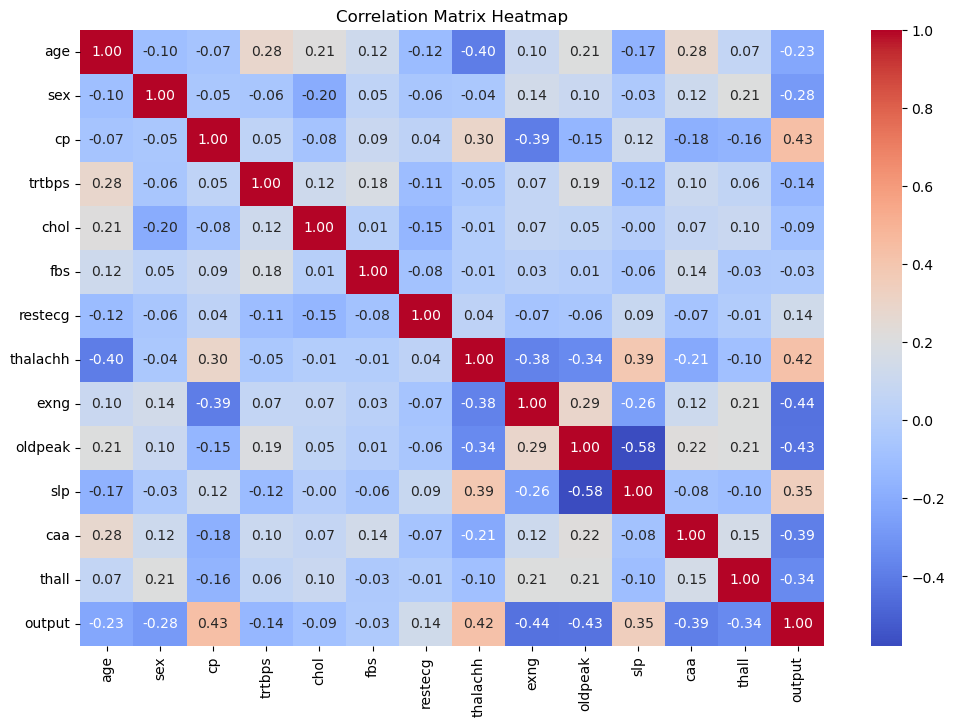

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap= 'coolwarm', cbar= True)
## annot= '각 셀에 수치를 표기할지'
## fmt=   'annot= True일 시 숫자 표기 형식'
## cmap=  '값의 크기별 색상 스타일'
## cbar=  '컬러바 표시 여부 - cmap의 색상별 수치 설명하는 막대'

plt.title('Correlation Matrix Heatmap')
plt.show

## 2. 교차분석

In [ ]:
'''
교차분석은 두 개 이상의 범주형 변수 간의 관계를 분석하는 방법이다.
주로 범주형(0 or 1) 데이터에서 변수 간의 빈도 분포 비교나 변수간 상호 연관성 파악에 사용된다.

데이터를 행과 열로 나누어 교차표 형태로 표현한다.



데이터프레임의 범주형 변수들을 지정해 매개변수에 입력하면
두 변수의 교차분석 결과를 DataFrame 형태로 반환한다.
'''

In [14]:
import pandas as pd # pandas 라이브러리 임포트 
file_path = "datasets/heart.csv" # 파일 경로
df = pd.read_csv(file_path)
df.head(5)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [15]:
# 교차표 생성 
crosstab = pd.crosstab(df['sex'], df['output']) 
# 교차표 출력 
print("교차표(빈도):\n")
print(crosstab)

교차표(빈도):

output    0   1
sex            
0        24  72
1       114  93


In [16]:
# 행 기준 비율 계산
row_percentage = pd.crosstab(df['sex'], df['output'], normalize='index') * 100
print("\n행 기준 비율:\n")
print(row_percentage)

# 열 기준 비율 계산
col_percentage = pd.crosstab(df['sex'], df['output'], normalize='columns') * 100
print("\n열 기준 비율:\n")
print(col_percentage)

# 전체 기준 비율 계산
total_percentage = pd.crosstab(df['sex'], df['output'], normalize=True) * 100
print("\n전체 기준 비율:\n")
print(total_percentage)

# 전체 기준 비율 계산 및 합계 포함
total_percentage_with_totals = pd.crosstab(df['sex'], df['output'], normalize=True, margins=True) * 100
total_percentage_with_totals = total_percentage_with_totals.round(2)
print("\n전체 기준 비율 (합계 포함):\n") 
print(total_percentage_with_totals)


행 기준 비율:

output          0          1
sex                         
0       25.000000  75.000000
1       55.072464  44.927536

열 기준 비율:

output          0          1
sex                         
0       17.391304  43.636364
1       82.608696  56.363636

전체 기준 비율:

output          0          1
sex                         
0        7.920792  23.762376
1       37.623762  30.693069

전체 기준 비율 (합계 포함):

output      0      1     All
sex                         
0        7.92  23.76   31.68
1       37.62  30.69   68.32
All     45.54  54.46  100.00


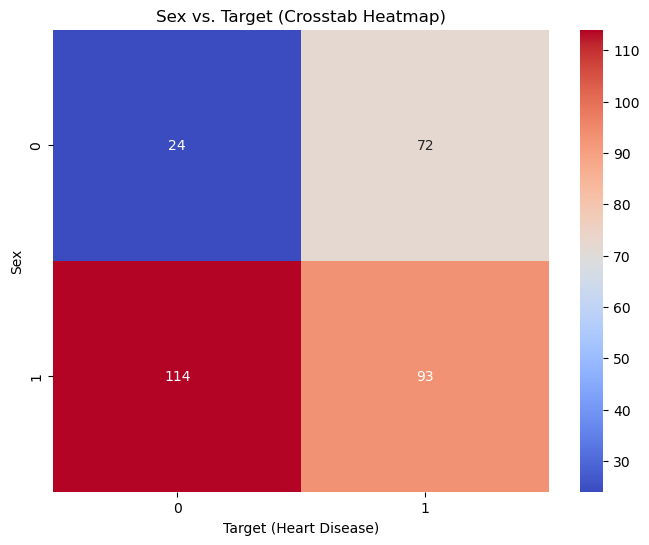

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 교차표를 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="coolwarm", cbar=True)
plt.title("Sex vs. Target (Crosstab Heatmap)")
plt.xlabel("Target (Heart Disease)")
plt.ylabel("Sex")
plt.show()